# **Reasoning and Planning in CrewAI**


## Demo: Reasoning  → Planning → Planning + Reasoning

## **Reasoning** answers: "How should I perform my task?"

## **Planning** answers: "How should this crew execute the overall workflow?"

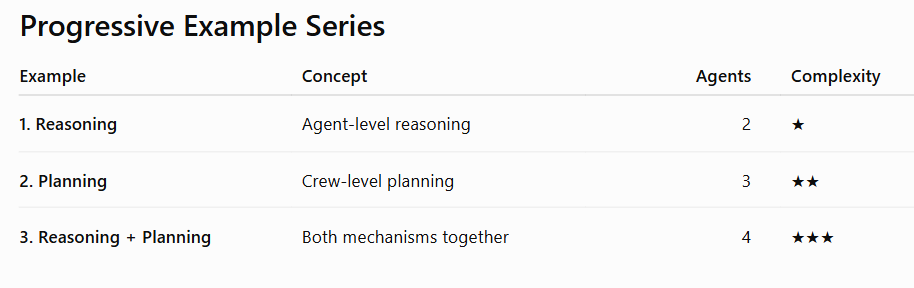

# Install Libraries

In [1]:
!pip install -q crewai crewai_tools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.5/195.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.2/833.2 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.5/252.5 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4

# Version Check

After successful installation....

In [2]:
import crewai
import crewai_tools
print(crewai.__version__)
print(crewai_tools.__version__)

1.15.16
1.15.16


# Set API Keys for LLMs & Tools

In [4]:
from google.colab import userdata
import os
# os.environ["SERPER_API_KEY"] = userdata.get('SERPER_API_KEY')
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY_NEW')
# os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

# Import necessary classes/methods from the package

In [2]:
from crewai import Agent, Task, Crew, LLM, Process
# from crewai_tools import SerperDevTool

# Define the LLM Object

In [5]:
# Create an LLM with a temperature of 0 to ensure deterministic outputs from the LLM
# Set temperature to higher values for creative outputs from the LLM

# OPENAI LLMs
llm = LLM(
          model="gpt-5.4-nano",
          base_url="https://api.openai.com/v1",
          api_key = os.environ["OPENAI_API_KEY"],
          temperature=0.7)

planning_llm = LLM(
        #   model="gpt-4o-mini",
          model="gpt-5.4-mini",
          base_url="https://api.openai.com/v1",
          api_key = os.environ["OPENAI_API_KEY"],
          temperature=0.7)


# **Example 1 — Agent Reasoning (Make an agent think before acting)**

## Problem: Build a two-agent crew that analyzes an AI technology and produces an evaluation report.

The important objective is not to make the workflow complicated. Instead, students should observe how reasoning=True changes the behavior of an individual agent.

## Workflow

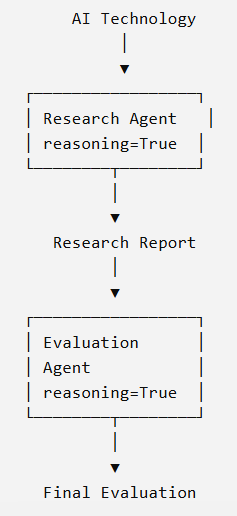

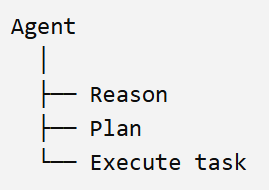

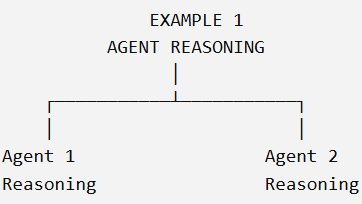

In [ ]:
from crewai import Agent, Task, Crew, Process


# ============================================================
# 1. AGENTS
# ============================================================

research_agent = Agent(
    role="AI Technology Researcher",

    goal=(
        "Research an AI technology and identify its major "
        "capabilities, applications, advantages and limitations."
    ),

    backstory=(
        "You are an experienced AI researcher who evaluates "
        "emerging AI technologies for technical organizations."
    ),

    llm=llm,

    # Enable agent-level reasoning
    reasoning=True,

    # Limit the number of reasoning refinements
    max_reasoning_attempts=3,

    verbose=True,
)

#------------------------------------------------------------

evaluation_agent = Agent(
    role="AI Technology Evaluator",

    goal=(
        "Evaluate the technology using the research provided "
        "and produce a balanced technical assessment."
    ),

    backstory=(
        "You are a senior AI consultant who evaluates whether "
        "emerging AI technologies are suitable for real-world adoption."
    ),

    llm=llm,

    reasoning=True,

    max_reasoning_attempts=3,

    verbose=True,
)


# ============================================================
# 2. TASKS
# ============================================================

research_task = Task(
    description="""
    Research the following AI technology:

    {technology}

    Analyze:

    1. What the technology is
    2. How it works at a high level
    3. Major capabilities
    4. Major applications
    5. Advantages
    6. Limitations
    7. Important implementation considerations

    Produce an evidence-oriented research report.
    """,

    expected_output="""
    A structured research report containing:

    - Technology Overview
    - How It Works
    - Major Capabilities
    - Applications
    - Advantages
    - Limitations
    - Implementation Considerations
    """,

    agent=research_agent,
)

#------------------------------------------------------------

evaluation_task = Task(
    description="""
    Evaluate the following AI technology:

    {technology}

    Use the research produced by the previous agent.

    Evaluate:

    1. Technical maturity
    2. Business usefulness
    3. Implementation difficulty
    4. Major risks
    5. Suitable use cases
    6. Unsuitable use cases
    7. Overall adoption recommendation

    Provide a balanced conclusion.
    """,

    expected_output="""
    A technical evaluation containing:

    - Executive Summary
    - Technical Assessment
    - Business Assessment
    - Risks
    - Suitable Use Cases
    - Unsuitable Use Cases
    - Adoption Recommendation
    """,

    agent=evaluation_agent,

    context=[research_task],
)


# ============================================================
# 3. CREW
# ============================================================

crew = Crew(
    agents=[
        research_agent,
        evaluation_agent,
    ],

    tasks=[
        research_task,
        evaluation_task,
    ],

    process=Process.sequential,

    # IMPORTANT:
    # planning=False / omitted.
    # We are studying agent reasoning only.

    verbose=True,
)


# ============================================================
# 4. EXECUTION
# ============================================================

if __name__ == "__main__":

    # technology = input(
    #     "Enter an AI technology to evaluate: "
    # )

    technology ="Agentic AI"

    result = await crew.kickoff_async(
        inputs={
            "technology": technology
        }
    )

    print("\n")
    print("=" * 80)
    print("FINAL EVALUATION")
    print("=" * 80)
    print(result)

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: d30932a4-d0a8-4894-a69f-5a982020786e                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│      Research the following AI technology:                                                                      │
│                                                                                                                 │
│      Agentic AI                                                                                                 │
│                                                                                                                 │
│      Analyze:                                                                                                   │
│                                                                                                                 │
│      1. What the technology is                                                                                  │
│      2. How it works at a high level                                                                            │
│      3. Major capabilities                                                                                      │
│      4. Major applications                                                                                      │
│      5. Advantages                                                                                              │
│      6. Limitations                                                                                             │
│      7. Important implementation considerations                                                                 │
│                                                                                                                 │
│      Produce an evidence-oriented research report.                                                              │
│                                                                                                                 │
│  ID: 340021b0-0688-4b3a-ad6f-44e475bffa62                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────── 🧠 Reasoning ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  Reasoning Started                                                                                              │
│  Attempt: 1                                                                                                     │
│  Status: Thinking...                                                                                            │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#1) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: create_reasoning_plan                                                                                    │
│  Args: {'plan': 'Create an evidence-oriented research report on Agentic AI by defining the concept, mapping     │
│  high-level mechanisms, enumerating capabilities/applications/advantages/limitations, and translatin...         │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────── ✅ Tool Execution Completed (#1) ────────────────────────────────────────╮
│                                                                                                                 │
│  Tool Completed                                                                                                 │
│  Tool: create_reasoning_plan                                                                                    │
│  Output: {"plan": "Create an evidence-oriented research report on Agentic AI by defining the concept, mapping   │
│  high-level mechanisms, enumerating capabilities/applications/advantages/limitations, and translating findings  │
│  into concrete implementation considerations\u2014each backed by citations from credible sources.", "steps":    │
│  [{"step_number": 1, "description": "Define the scope and working definition of \u201cAgentic AI\u201d by       │
│  writing a 5\u20138 sentence description of what qualifies as agentic AI vs. adjacent terms (e.g., chatbots,    │
│  workflow automation, tool use). DONE: the definition explicitly states inclusion/exclusion criteria and fits   │
│  within 150 words.", "tool_to_use": null, "depends_on": []}, {"step_number": 2, "description": "Collect         │
│  8\u201312 authoritative sources (papers, reputable industry research, and/or documentation) that directly      │
│  discuss agentic AI concepts, architectures, or systems. DONE: a bibliography table (source, author/org, year,  │
│  URL/DOI) with at least 8 entries is produced.", "tool_to_use": null, "depends_on": []}, {"step_number": 3,     │
│  "description": "For each collected source, extract 2\u20134 key factual claims relevant to: definition,        │
│  mechanisms, capabilities, applications, advantages, limitations, and implementation. DONE: an evidence matrix  │
│  is created with rows=source and columns=categories; each cell contains a quoted or paraphrased claim plus      │
│  page/section reference.", "tool_to_use": null, "depends_on": [2]}, {"step_number": 4, "description":           │
│  "Synthesize \u201cTechnology Overview\u201d by drafting a structured section (bullets + short paragraphs)      │
│  that explains what agentic AI is, typical components, and how it differs from non-agentic LLM usage. DONE:     │
│  the section contains at least 6 distinct points and each point is linked to at least one source claim from     │
│  the evidence matrix.", "tool_to_use": null, "depends_on": [1, 3]}, {"step_number": 5, "description": "Explain  │
│  \u201cHow It Works\u201d at a high level by producing a step-by-step pipeline (e.g., goal/input \u2192         │
│  planning \u2192 tool selection \u2192 action execution \u2192 observation \u2192 iteration \u2192 completion)  │
│  and stating where LLMs and/or controllers fit. DONE: the pipeline has 6\u201310 steps and includes a brief     │
│  note on feedback/iteration and state/memory; every step cites evidence.", "tool_to_use": null, "depends_on":   │
│  [3]}, {"step_number": 6, "description": "Identify and list \u201cMajor Capabilities\u201d by consolidating     │
│  claims across sources into a categorized taxonomy (e.g., planning, tool use, autonomy/looping, multi-agent     │
│  collaboration, memory/context management, robustness/error handling). DONE: at least 8 capabilities are        │
│  listed with supporting evidence citations.", "tool_to_use": null, "depends_on": [3]}, {"step_number": 7,       │
│  "description": "Identify \u201cMajor Applications\u201d by mapping capabilities to concrete use cases (e.g.,   │
│  software engineering copilots, customer support with action, research agents, operations/IT automation,        │
│  finance ops, data analysis, robotics). DONE: at least 10 applications are provided, each tagged with which     │
│  capability(s) enable it and backed by evidence.", "tool_to_use": null, "depends_on": [3]}, {"step_number": 8,  │
│  "description": "Analyze \u201cAdvantages\u201d by extr

...

[CrewAIEventsBus] Warning: Event pairing mismatch. 'llm_call_failed' closed 'flow_started' (expected 
'llm_call_started')

ERROR:root:OpenAI API call failed: cannot schedule new futures after shutdown


[CrewAIEventsBus] Warning: Event pairing mismatch. 'llm_call_failed' closed 'agent_execution_started' (expected 
'llm_call_started')

Exception ignored in: <module 'threading' from '/usr/lib/python3.12/threading.py'>
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1594, in _shutdown
    atexit_call()
  File "/usr/lib/python3.12/concurrent/futures/thread.py", line 31, in _python_exit
    t.join()
  File "/usr/lib/python3.12/threading.py", line 1149, in join
    self._wait_for_tstate_lock()
  File "/usr/lib/python3.12/threading.py", line 1169, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/crewai/telemetry/telemetry.py", line 241, in handler
    raise SystemExit(0)
SystemExit: 0


[CrewAIEventsBus] Warning: Attempted to emit event during shutdown. Ignoring.

# **Example 2 — Crew Planning (Make the crew think before executing)**

Now we increase the complexity.

Instead of asking individual agents to reason about their tasks, we give the entire crew a planning capability. We'll add a third agent.

Problem: Build a three-agent crew that produces a comprehensive AI technology adoption report.

Workflow

## The crew planner looks at the entire workflow, rather than an individual agent deciding how to reason about its own task.


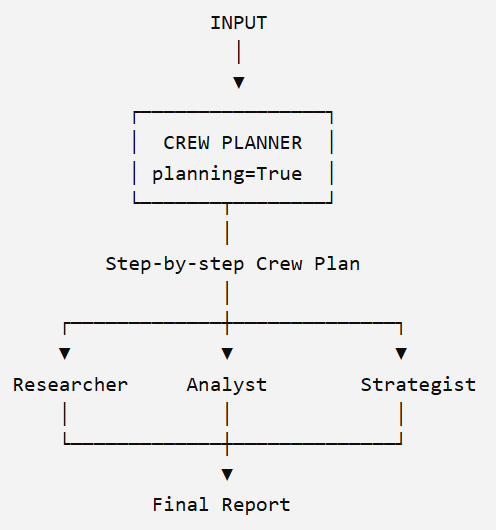

## CrewAI sends the crew's information to an AgentPlanner, which creates a step-by-step plan and adds that plan to the task descriptions.


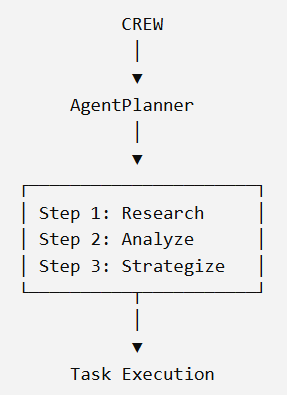

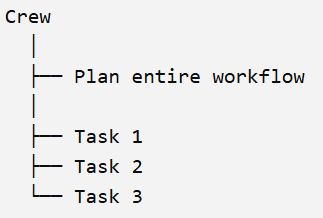

In [ ]:
from crewai import Agent, Task, Crew, Process


# ============================================================
# 1. AGENTS
# ============================================================

research_agent = Agent(
    role="AI Technology Researcher",

    goal=(
        "Research the technology and provide reliable technical "
        "and market information."
    ),

    backstory=(
        "You are an AI researcher specializing in emerging "
        "AI technologies and their applications."
    ),

    llm=llm,

    verbose=True,
)


business_analyst = Agent(
    role="AI Business Analyst",

    goal=(
        "Analyze the business value, opportunities, risks and "
        "implementation considerations of the technology."
    ),

    backstory=(
        "You are a technology business analyst experienced in "
        "evaluating AI adoption strategies."
    ),

    llm=llm,

    verbose=True,
)


strategy_agent = Agent(
    role="AI Strategy Consultant",

    goal=(
        "Develop an adoption strategy based on technical and "
        "business analysis."
    ),

    backstory=(
        "You are a senior technology strategy consultant who "
        "helps organizations adopt emerging technologies."
    ),

    llm=llm,

    verbose=True,
)


# ============================================================
# 2. TASKS
# ============================================================

research_task = Task(
    description="""
    Research:

    {technology}

    Analyze:

    - Technology overview
    - Technical capabilities
    - Architecture/concepts
    - Major applications
    - Industry trends
    - Advantages
    - Limitations
    """,

    expected_output="""
    A comprehensive technical research report.
    """,

    agent=research_agent,
)

#-------------------------------------------------------

business_task = Task(
    description="""
    Evaluate the business implications of:

    {technology}

    Using the research provided by the previous task, analyze:

    - Business opportunities
    - Potential ROI drivers
    - Target users
    - Competitive implications
    - Implementation challenges
    - Risks
    """,

    expected_output="""
    A structured business analysis containing opportunities,
    risks, implementation challenges and business value.
    """,

    agent=business_analyst,

    context=[research_task],
)

#-------------------------------------------------------

strategy_task = Task(
    description="""
    Develop an adoption strategy for:

    {technology}

    Use the technical research and business analysis.

    Produce:

    1. Strategic recommendation
    2. Priority use cases
    3. Adoption roadmap
    4. Major risks
    5. Mitigation strategies
    6. Success criteria
    """,

    expected_output="""
    A complete AI technology adoption strategy.
    """,

    agent=strategy_agent,

    context=[
        research_task,
        business_task,
    ],
)


# ============================================================
# 3. CREW WITH PLANNING
# ============================================================

crew = Crew(
    agents=[
        research_agent,
        business_analyst,
        strategy_agent,
    ],

    tasks=[
        research_task,
        business_task,
        strategy_task,
    ],

    process=Process.sequential,

    # Enable CREW-level planning
    planning=True,

    # Explicitly specify the planning LLM
    planning_llm=planning_llm,

    verbose=True,
)


# ============================================================
# 4. EXECUTION
# ============================================================

if __name__ == "__main__":

    # technology = input(
    #     "Enter an AI technology to analyze: "
    # )

    technology = "Multi-agent Systems"

    result = await crew.kickoff_async(
        inputs={
            "technology": technology
        }
    )

    print("\n")
    print("=" * 80)
    print("AI TECHNOLOGY ADOPTION STRATEGY")
    print("=" * 80)
    print(result)

# **Example 3 — Reasoning + Planning**

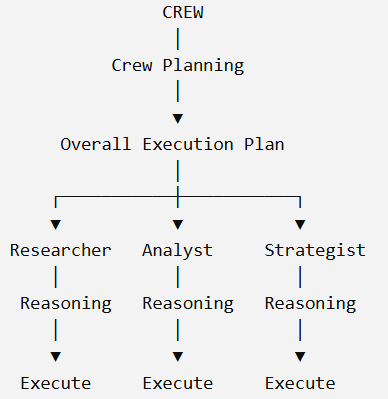

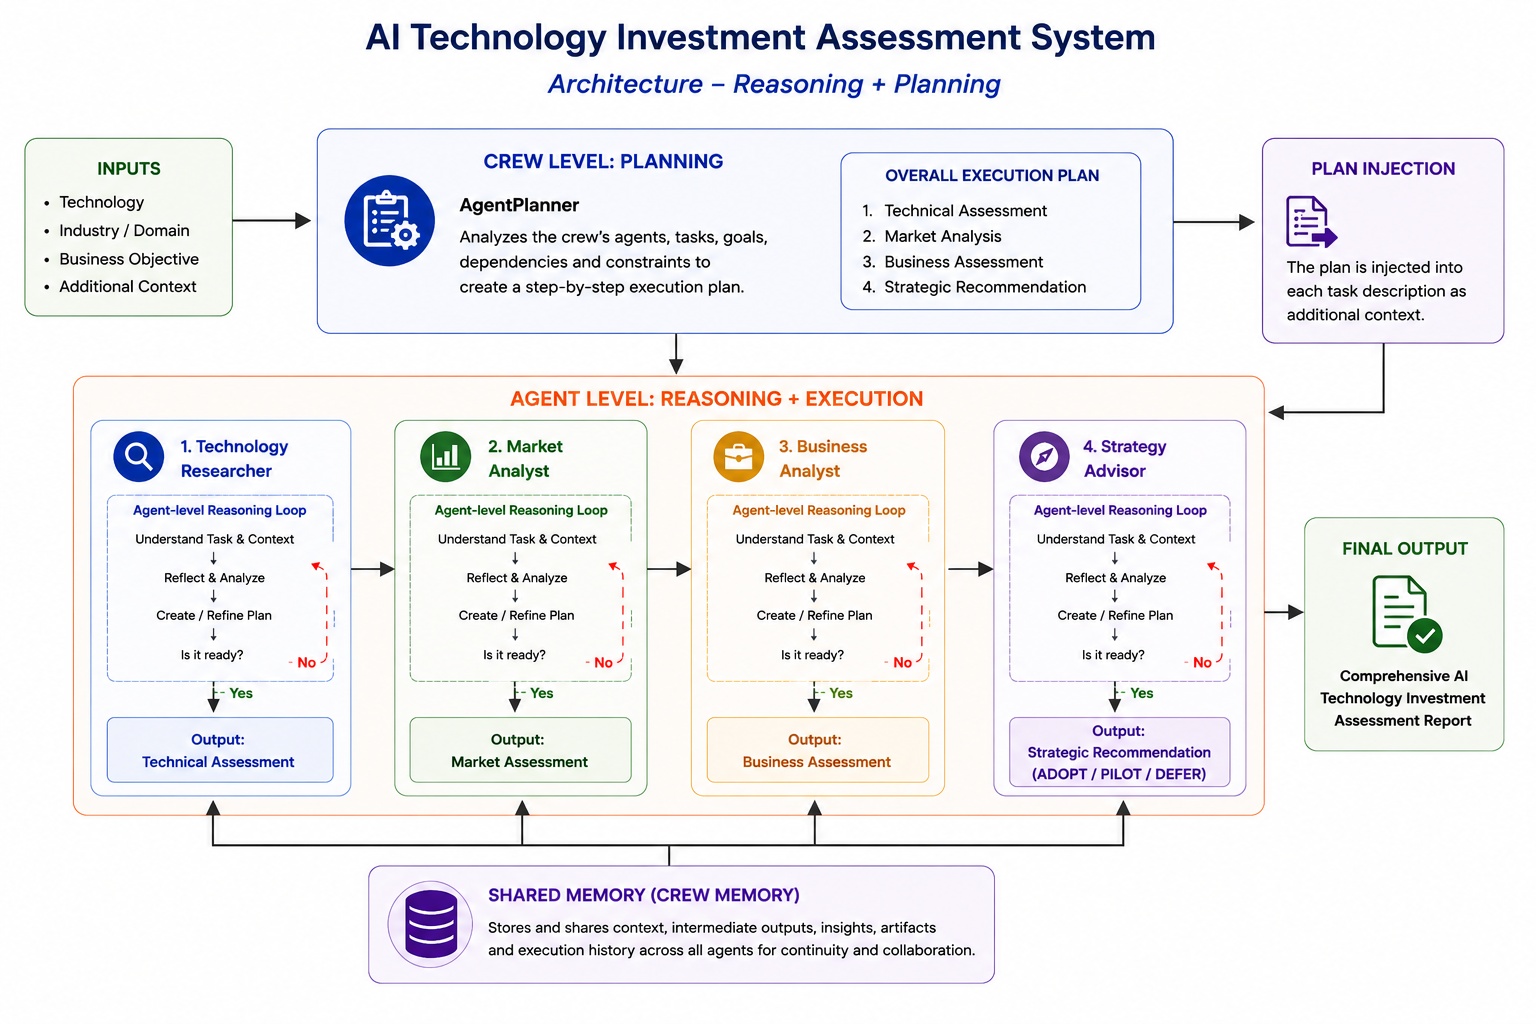

In [ ]:
from crewai import Agent, Task, Crew, Process


# ============================================================
# 1. AGENTS
# ============================================================

technology_researcher = Agent(
    role="AI Technology Researcher",

    goal=(
        "Perform deep technical research on the target "
        "AI technology."
    ),

    backstory=(
        "You are a senior AI researcher with expertise in "
        "machine learning, generative AI and emerging technologies."
    ),

    llm=llm,

    # AGENT-LEVEL REASONING
    reasoning=True,
    max_reasoning_attempts=3,

    verbose=True,
)

#-------------------------------------------------------

market_analyst = Agent(
    role="AI Market Analyst",

    goal=(
        "Analyze the market, competitive landscape and "
        "commercial potential of the technology."
    ),

    llm=llm,

    backstory=(
        "You are a market intelligence analyst specializing "
        "in AI and emerging technology markets."
    ),

    reasoning=True,
    max_reasoning_attempts=3,

    verbose=True,
)

#-------------------------------------------------------

business_analyst = Agent(
    role="AI Business Analyst",

    goal=(
        "Evaluate the business value, implementation challenges "
        "and organizational impact of the technology."
    ),

   llm=llm,

    backstory=(
        "You are a senior business analyst experienced in "
        "technology adoption and digital transformation."
    ),

    reasoning=True,
    max_reasoning_attempts=3,

    verbose=True,
)

#-------------------------------------------------------

strategy_advisor = Agent(
    role="AI Strategy Advisor",

    goal=(
        "Synthesize all analyses and produce a strategic "
        "technology adoption recommendation."
    ),

    llm=llm,

    backstory=(
        "You are a senior strategy consultant specializing "
        "in AI transformation and technology investment decisions."
    ),

    reasoning=True,
    max_reasoning_attempts=3,

    verbose=True,
)


# ============================================================
# 2. TASKS
# ============================================================

technology_task = Task(
    description="""
    Conduct a deep technical assessment of:

    Technology:
    {technology}

    Industry:
    {industry}

    Business objective:
    {objective}

    Analyze:

    1. Core technology
    2. Architecture/concepts
    3. Technical capabilities
    4. Maturity
    5. Advantages
    6. Limitations
    7. Implementation requirements
    8. Technical risks

    Produce an evidence-oriented technical assessment.
    """,

    expected_output="""
    A detailed technical assessment covering technology,
    capabilities, maturity, implementation requirements,
    limitations and technical risks.
    """,

    agent=technology_researcher,
)

#-------------------------------------------------------

market_task = Task(
    description="""
    Analyze the market surrounding:

    {technology}

    Industry:
    {industry}

    Business objective:
    {objective}

    Use the available technical assessment.

    Analyze:

    1. Market opportunity
    2. Market growth
    3. Major competitors
    4. Competitive advantages
    5. Market threats
    6. Commercial opportunities
    7. Market risks
    """,

    expected_output="""
    A structured market analysis covering opportunity,
    competition, growth, commercial potential and risks.
    """,

    agent=market_analyst,

    context=[technology_task],
)

#-------------------------------------------------------

business_task = Task(
    description="""
    Evaluate the business implications of adopting:

    {technology}

    Industry:
    {industry}

    Business objective:
    {objective}

    Use the technical and market analyses.

    Analyze:

    1. Business value
    2. Potential ROI drivers
    3. Implementation complexity
    4. Organizational impact
    5. Required capabilities
    6. Major risks
    7. Adoption barriers
    """,

    expected_output="""
    A detailed business assessment containing business value,
    ROI drivers, implementation complexity, organizational
    impact and adoption barriers.
    """,

    agent=business_analyst,

    context=[
        technology_task,
        market_task,
    ],
)

#-------------------------------------------------------

strategy_task = Task(
    description="""
    Develop a final strategic recommendation for:

    Technology:
    {technology}

    Industry:
    {industry}

    Business objective:
    {objective}

    Use all previous analyses.

    Your final report must contain:

    1. Executive Summary
    2. Technical Assessment
    3. Market Assessment
    4. Business Assessment
    5. Opportunities
    6. Risks
    7. Adoption Strategy
    8. Implementation Roadmap
    9. Success Metrics
    10. Final Recommendation

    The final recommendation must be one of:

    - ADOPT
    - PILOT
    - DEFER

    Explain the reasoning behind the recommendation.
    """,

    expected_output="""
    A comprehensive strategic technology assessment with
    a final ADOPT, PILOT or DEFER recommendation.
    """,

    agent=strategy_advisor,

    context=[
        technology_task,
        market_task,
        business_task,
    ],
)


# ============================================================
# 3. CREW
# ============================================================

crew = Crew(
    agents=[
        technology_researcher,
        market_analyst,
        business_analyst,
        strategy_advisor,
    ],

    tasks=[
        technology_task,
        market_task,
        business_task,
        strategy_task,
    ],

    process=Process.sequential,

    # ========================================================
    # CREW-LEVEL PLANNING
    # ========================================================

    planning=True,

    planning_llm=planning_llm,

    verbose=True,
)


# ============================================================
# 4. EXECUTION
# ============================================================

if __name__ == "__main__":

    # technology = input(
    #     "Technology: "
    # )

    # industry = input(
    #     "Industry: "
    # )

    # objective = input(
    #     "Business objective: "
    # )


    technology = "Agentic AI"
    industry = " Software Development"
    objective = "Return on Investment"


    result = await crew.kickoff_async(
        inputs={
            "technology": technology,
            "industry": industry,
            "objective": objective,
        }
    )

    print("\n")
    print("=" * 80)
    print("FINAL TECHNOLOGY STRATEGY REPORT")
    print("=" * 80)
    print(result)

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 00f20e8e-80b4-488c-b92f-4232972ae48e                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


[2026-08-17 12:25:45][INFO]: Planning the crew execution


╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Based on these tasks summary:                                                                            │
│                  Task Number 1 -                                                                                │
│      Conduct a deep technical assessment of:                                                                    │
│                                                                                                                 │
│      Technology:                                                                                                │
│      Agentic AI                                                                                                 │
│                                                                                                                 │
│      Industry:                                                                                                  │
│       Software Development                                                                                      │
│                                                                                                                 │
│      Business objective:                                                                                        │
│      Return on Investment                                                                                       │
│                                                                                                                 │
│      Analyze:                                                                                                   │
│                                                                                                                 │
│      1. Core technology                                                                                         │
│      2. Architecture/concepts                                                                                   │
│      3. Technical capabilities                                                                                  │
│      4. Maturity                                                                                                │
│      5. Advantages                                                                                              │
│      6. Limitations                                                                                             │
│      7. Implementation requirements                                                                             │
│      8. Technical risks                                                                                         │
│                                                                                                                 │
│      Produce an evidence-oriented technical assessment.                                                         │
│                                                                                                                 │
│                  "task_description":                                                                            │
│      Conduct a deep technical assessment of:                                                                    │
│                                                                                                                 │
│      Technology:                                                                                                │
│      Agentic AI                                                                                                 │
│                                                        

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Based on these tasks summary:                                                                            │
│                  Task Number 1 -                                                                                │
│      Conduct a deep technical assessment of:                                                                    │
│                                                                                                                 │
│      Technology:                                                                                                │
│      Agentic AI                                                                                                 │
│                                                                                                                 │
│      Industry:                                                                                                  │
│       Software Development                                                                                      │
│                                                                                                                 │
│      Business objective:                                                                                        │
│      Return on Investment                                                                                       │
│                                                                                                                 │
│      Analyze:                                                                                                   │
│                                                                                                                 │
│      1. Core technology                                                                                         │
│      2. Architecture/concepts                                                                                   │
│      3. Technical capabilities                                                                                  │
│      4. Maturity                                                                                                │
│      5. Advantages                                                                                              │
│      6. Limitations                                                                                             │
│      7. Implementation requirements                                                                             │
│      8. Technical risks                                                                                         │
│                                                                                                                 │
│      Produce an evidence-oriented technical assessment.                                                         │
│                                                                                                                 │
│                  "task_description":                                                                            │
│      Conduct a deep technical assessment of:                                                                    │
│                                                                                                                 │
│      Technology:                                                                                                │
│      Agentic AI                                                                                                 │
│                                                        

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│      Conduct a deep technical assessment of:                                                                    │
│                                                                                                                 │
│      Technology:                                                                                                │
│      Agentic AI                                                                                                 │
│                                                                                                                 │
│      Industry:                                                                                                  │
│       Software Development                                                                                      │
│                                                                                                                 │
│      Business objective:                                                                                        │
│      Return on Investment                                                                                       │
│                                                                                                                 │
│      Analyze:                                                                                                   │
│                                                                                                                 │
│      1. Core technology                                                                                         │
│      2. Architecture/concepts                                                                                   │
│      3. Technical capabilities                                                                                  │
│      4. Maturity                                                                                                │
│      5. Advantages                                                                                              │
│      6. Limitations                                                                                             │
│      7. Implementation requirements                                                                             │
│      8. Technical risks                                                                                         │
│                                                                                                                 │
│      Produce an evidence-oriented technical assessment.                                                         │
│      1. Start by defining the scope precisely: treat Agentic AI as autonomous or semi-autonomous AI systems     │
│  that can plan, reason, call tools, execute multi-step workflows, and iterate toward goals in software          │
│  development contexts.                                                                                          │
│  2. Frame the assessment around evidence-oriented technical criteria: identify what is known from established   │
│  AI system patterns, what is emerging, and what remains speculative; separate capabilities demonstrated in      │
│  production from capabilities shown only in prototypes.                                                         │
│  3. Analyze the core technology by decomposing it into its main building blocks: foundation models, prompt      │
│  orchestration, tool/function calling, memory, planning

...

╭───────────────────────────────────────────── 🔍 Observation Result ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Observation Complete                                                                                           │
│  Step: 12                                                                                                       │
│  Status: Plan Valid — Continue                                                                                  │
│  Learned: Step 12 produced and verified a concrete limitations/failure-modes table for Agentic AI in software   │
│  development, stored ...                                                                                        │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── 🔍 Observing Step Result ────────────────────────────────────────────╮
│                                                                                                                 │
│  Observation Started                                                                                            │
│  Agent: AI Technology Researcher                                                                                │
│  Step: 13                                                                                                       │
│  Description: Specify implementation requirements for software development environments: repo/...               │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[Observe] Step 13 (effort=medium): success=True, plan_valid=False, learned=Step 13 produced a concrete implementation requirements checklist artifact at `/...


╭───────────────────────────────────────────── 🔍 Observation Result ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Observation Complete                                                                                           │
│  Step: 13                                                                                                       │
│  Status: Step Failed                                                                                            │
│  Learned: Step 13 produced a concrete implementation requirements checklist artifact at                         │
│  `/app/agentic_ai_implementation_requiremen...                                                                  │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Exception ignored in: <module 'threading' from '/usr/lib/python3.12/threading.py'>
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1594, in _shutdown
    atexit_call()
  File "/usr/lib/python3.12/concurrent/futures/thread.py", line 31, in _python_exit
    t.join()
  File "/usr/lib/python3.12/threading.py", line 1149, in join
    self._wait_for_tstate_lock()
  File "/usr/lib/python3.12/threading.py", line 1169, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/crewai/telemetry/telemetry.py", line 232, in handler
    crewai_event_bus.emit(self, event_class())
  File "/usr/local/lib/python3.12/dist-packages/crewai/events/event_bus.py", line 633, in emit
    sync_future = self._sync_executor.submit(
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/concurrent/futures/thread.py", line 171, in submit
    raise RuntimeError('cannot schedule